In [1]:
import matplotlib.pyplot as plt
import pandas as pd

import scarf

scarf.configure_output(level='WARNING', progress=True)

In [2]:
dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name='tenx_5K_pbmc_rnaseq',
    zarr=True,
    destination='scarf_datasets'
)

Downloading bucket files: 38209567 / 38209567 complete

Downloading bytes: 38209567 / 38209567 complete

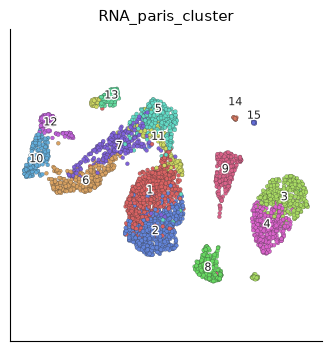

In [3]:
ds = scarf.DataStore(f'{dataset}/data.zarr')

ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_paris_cluster',
)

In [4]:
ds.run_topacedo_sampler(
    cluster_key='RNA_paris_cluster',
    max_sampling_rate=0.1
)
if 'RNA_sketched' not in ds.cells.columns:
    raise RuntimeError(
        "TopACeDo did not create RNA_sketched. Verify that topacedo is installed."
    )

{
    'active cells': int(ds.cells.fetch_all('I').sum()),
    'seed cells': int(ds.cells.fetch_all('RNA_sketch_seeds').sum()),
    'selected cells': int(ds.cells.fetch_all('RNA_sketched').sum()),
}

INFO: 368 cells (9.34%) sub-sampled. Subsample to Seed (158 cells) ratio: 2.329


Constructing graph from dendrogram: 3939 / 3939 complete

{'active cells': 3940, 'seed cells': 158, 'selected cells': 368}

In [5]:
sampling = ds.cells.to_pandas_dataframe(
    columns=['RNA_paris_cluster', 'RNA_sketched', 'RNA_sketch_seeds'],
    key='I',
)
cluster_sampling = sampling.groupby('RNA_paris_cluster', sort=True).agg(
    cells=('RNA_paris_cluster', 'size'),
    seeds=('RNA_sketch_seeds', 'sum'),
    selected=('RNA_sketched', 'sum'),
)
cluster_sampling['sampling_rate'] = (
    cluster_sampling['selected'] / cluster_sampling['cells']
).round(3)
cluster_sampling

,cells,seeds,selected,sampling_rate
RNA_paris_cluster,,,,
1,685,13,36,0.053
2,546,12,27,0.049
3,366,15,35,0.096
4,356,15,32,0.090
5,305,12,28,0.092
6,296,17,39,0.132
7,261,10,26,0.100
8,252,11,28,0.111
9,248,10,22,0.089


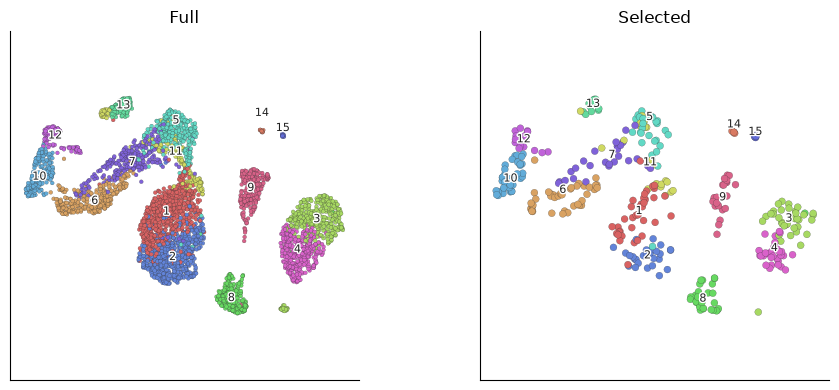

In [6]:
figure, axes = plt.subplots(1, 2, figsize=(10, 4))
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_paris_cluster',
    legend_loc='on_data',
    show_titles=False,
    target=axes[0],
    show=False,
)
axes[0].set_title('Full')
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_paris_cluster',
    subset_by='RNA_sketched',
    legend_loc='on_data',
    show_titles=False,
    target=axes[1],
    show=False,
)
axes[1].set_title('Selected')
figure.tight_layout()
figure

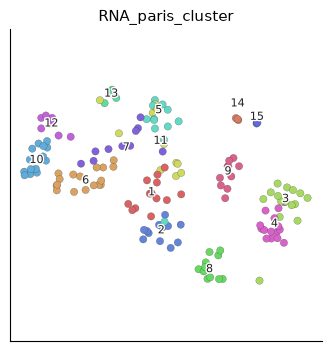

In [7]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_paris_cluster',
    subset_by='RNA_sketch_seeds',
)

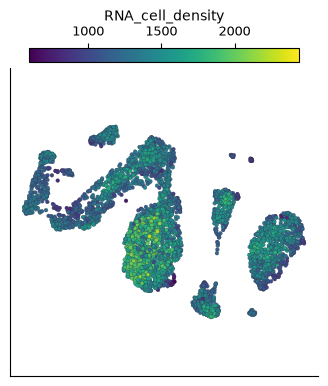

In [8]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_cell_density',
)

In [9]:
density = ds.cells.to_pandas_dataframe(
    columns=['RNA_cell_density', 'RNA_sketched'],
    key='I',
)
density['density_bin'] = pd.qcut(
    density['RNA_cell_density'],
    q=5,
    duplicates='drop',
)
(
    density.groupby('density_bin', observed=True)
    .agg(
        cells=('RNA_sketched', 'size'),
        selected=('RNA_sketched', 'sum'),
    )
    .assign(
        selection_rate=lambda frame: (
            frame['selected'] / frame['cells']
        ).round(3)
    )
)

,cells,selected,selection_rate
density_bin,,,
"(598.381, 1200.649]",788,80,0.102
"(1200.649, 1352.935]",788,95,0.121
"(1352.935, 1481.896]",788,87,0.110
"(1481.896, 1655.521]",788,56,0.071
"(1655.521, 2438.626]",788,50,0.063


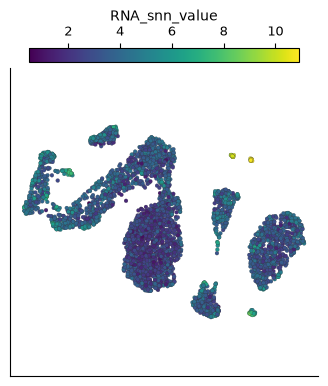

In [10]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_snn_value',
)

In [11]:
subset_path = f'{dataset}/subset.zarr'
writer = scarf.SubsetZarr(
    zarr_loc=subset_path,
    assays=[ds.RNA],
    cell_key='RNA_sketched',
    reset_cell_filter=False,
    overwrite_existing_file=True,
)
writer.dump()

Subsetting assay: RNA: 1 / 1 complete

In [12]:
ds2 = scarf.DataStore(subset_path)
{
    "source cells": ds.cells.N,
    "subset cells": ds2.cells.N,
    "source RNA features": ds.RNA.feats.N,
    "subset RNA features": ds2.RNA.feats.N,
}

Computing RNA initialization statistics: 1 / 1 complete

{'source cells': 5025,
 'subset cells': 368,
 'source RNA features': 33538,
 'subset RNA features': 33538}

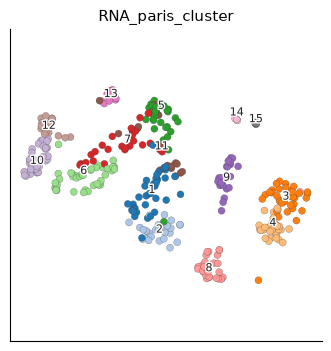

In [13]:
ds2.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_paris_cluster',
)

In [14]:
adata = ds2.to_anndata()
adata.shape

Converting RNA raw data to CSR: 1 / 1 complete

(368, 33538)